In [21]:
import pandas as pd
import numpy as np

from sklearn.neighbors import BallTree
from pathlib import Path
from pyproj import Transformer
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

EARTH_RADIUS_M = 6_371_000
MAX_DIST_M = 30

In [22]:
# 1) DVF first (lighter RAM) — run estimate ~2m
dvf_dir = Path("../../ml/csv_data/dvf_plus")

DVF_USECOLS = [
    "datemut",
    "anneemut",
    "valeurfonc",
    "sbati",
    "sterr",
    "codtypbien",
    "idnatmut",
    "l_codinsee",
    "nblocdep",
    "nbapt1pp",
    "nbapt2pp",
    "nbapt3pp",
    "nbapt4pp",
    "nbapt5pp",
    "geompar_x",
    "geompar_y",
]

dfs_dvf = [
    pd.read_csv(path, sep="|", usecols=DVF_USECOLS, low_memory=False)
    for path in sorted(dvf_dir.glob("*.csv"))
]

df_dvf = pd.concat(dfs_dvf, ignore_index=True)
del dfs_dvf

df_dvf.shape

(16565022, 16)

In [23]:
# lon / lat from Lambert-93
transformer = Transformer.from_crs("EPSG:2154", "EPSG:4326", always_xy=True)

df_dvf["lon"], df_dvf["lat"] = transformer.transform(
    df_dvf["geompar_x"].to_numpy(),
    df_dvf["geompar_y"].to_numpy(),
)

In [24]:
# Filter apartments only (121 = apartment)
df_dvf_filtered = df_dvf[
    (df_dvf["idnatmut"] == 1)  # 1 = sale
    & (df_dvf["codtypbien"] == 121)
    & (df_dvf["anneemut"] >= 2023)
    & (df_dvf["valeurfonc"] > 10_000)
    & (df_dvf["sbati"] > 10)
    # France metropolitan
    & (df_dvf["lon"] >= -5.5)
    & (df_dvf["lon"] <= 10)
    & (df_dvf["lat"] >= 41)
    & (df_dvf["lat"] <= 51.5)
    & ((df_dvf["valeurfonc"] / df_dvf["sbati"]).between(500, 15_000))
    & (df_dvf["sterr"] >= 0)
    & (df_dvf["sterr"] <= 5_000)
].copy()

del df_dvf
df_dvf_filtered.drop(columns=["geompar_x", "geompar_y"], inplace=True, errors="ignore")

df_dvf_filtered.shape

(975019, 16)

In [25]:
df_dvf_filtered["apartement_rooms"] = (
    1 * df_dvf_filtered["nbapt1pp"]
  + 2 * df_dvf_filtered["nbapt2pp"]
  + 3 * df_dvf_filtered["nbapt3pp"]
  + 4 * df_dvf_filtered["nbapt4pp"]
  + 5 * df_dvf_filtered["nbapt5pp"]
)

df_dvf_filtered.drop(
    columns=["nbapt1pp", "nbapt2pp", "nbapt3pp", "nbapt4pp", "nbapt5pp"],
    inplace=True,
)

In [26]:
# 2) DPE after DVF filter — run estimate ~1-2m
DPE_PATH = Path("../../ml/csv_data/dpe/dpe-france.csv")
DPE_LABEL_TO_SCORE = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}

dpe_cols = [
    "numero_dpe",
    "date_etablissement_dpe",
    "classe_consommation_energie",
    "annee_construction",
    "latitude",
    "longitude",
    "tr001_modele_dpe_type_libelle",
    "tr002_type_batiment_description",
]

df_dpe = pd.read_csv(DPE_PATH, usecols=dpe_cols, low_memory=False)

df_dpe = df_dpe[
    df_dpe["tr001_modele_dpe_type_libelle"].isin(
        ["Vente", "Location", "Neuf", "Copropriété"]
    )
]

df_dpe["date_etablissement_dpe"] = pd.to_datetime(
    df_dpe["date_etablissement_dpe"], errors="coerce"
)
today = pd.Timestamp.today().normalize()
current_year = today.year

df_dpe = df_dpe[df_dpe["date_etablissement_dpe"] <= today]
df_dpe = df_dpe[df_dpe["annee_construction"].between(1850, current_year)]

df_dpe["dpe_median"] = (
    df_dpe["classe_consommation_energie"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map(DPE_LABEL_TO_SCORE)
)

df_dpe = df_dpe.rename(columns={"latitude": "lat", "longitude": "lon"})
df_dpe = df_dpe.dropna(subset=["dpe_median", "annee_construction", "lat", "lon"])
df_dpe = df_dpe.drop_duplicates(subset=["numero_dpe"], keep="first")

building_type = df_dpe["tr002_type_batiment_description"].astype(str)
df_dpe_appart = df_dpe[
    building_type.str.contains("collectif", case=False, na=False)
    | (building_type == "Logement")
]

dpe_bat = (
    df_dpe_appart.groupby(["lat", "lon"], as_index=False)
    .agg(
        dpe_median=("dpe_median", "median"),
        annee_construction=("annee_construction", "first"),
    )
)
dpe_bat["dpe_median"] = dpe_bat["dpe_median"].round().astype(int)

del df_dpe, df_dpe_appart  # free RAM before spatial merge

print("DPE appart buildings:", len(dpe_bat))

DPE appart buildings: 824665


In [27]:
def merge_dpe_on_dvf(
    dvf_df: pd.DataFrame,
    dpe_bat: pd.DataFrame,
    max_dist_m: float = MAX_DIST_M,
) -> pd.DataFrame:
    result = dvf_df.copy()
    result["dpe_median"] = np.nan
    result["annee_construction"] = np.nan

    valid = result.dropna(subset=["lat", "lon"])
    dpe_ok = dpe_bat.dropna(subset=["lat", "lon"]).reset_index(drop=True)

    if valid.empty or dpe_ok.empty:
        return result

    dvf_rad = np.radians(valid[["lat", "lon"]].to_numpy())
    dpe_rad = np.radians(dpe_ok[["lat", "lon"]].to_numpy())

    tree = BallTree(dpe_rad, metric="haversine")
    dist, idx = tree.query(dvf_rad, k=1)

    dist_m = dist[:, 0] * EARTH_RADIUS_M
    match_idx = idx[:, 0].astype(float)
    match_idx[dist_m > max_dist_m] = np.nan

    dpe_idx = pd.Series(match_idx, index=valid.index)

    result.loc[valid.index, "dpe_median"] = dpe_idx.map(dpe_ok["dpe_median"])
    result.loc[valid.index, "annee_construction"] = dpe_idx.map(
        dpe_ok["annee_construction"]
    )

    match_rate = dpe_idx.notna().mean()
    print(f"Match DPE: {match_rate:.1%} ({dpe_idx.notna().sum()} / {len(valid)})")

    return result


df_dvf_filtered = merge_dpe_on_dvf(df_dvf_filtered, dpe_bat)
del dpe_bat

Match DPE: 60.4% (588734 / 975019)


In [28]:
COLUMNS_TO_KEEP = [
    "datemut",
    "l_codinsee",
    "lon",
    "lat",
    "sbati",
    "nblocdep",
    "sterr",
    "dpe_median",
    "annee_construction",
    "apartement_rooms",
    "valeurfonc",
]

df_dvf_filtered_cols = df_dvf_filtered[COLUMNS_TO_KEEP]
del df_dvf_filtered

In [29]:
# dropna without requiring DPE (XGBoost handles NaN)
df_dvf_filtered_cols.dropna(
    subset=[c for c in df_dvf_filtered_cols.columns if c not in ("dpe_median", "annee_construction")],
    inplace=True,
)
df_dvf_filtered_cols.drop_duplicates(inplace=True)
df_dvf_filtered_cols.head()

,datemut,l_codinsee,lon,lat,sbati,nblocdep,sterr,dpe_median,annee_construction,apartement_rooms,valeurfonc
121668,2023-11-20,01269,5.608898,46.148424,20.0,1,0.0,5.0,1969.0,1,28100.0
121674,2023-07-05,01173,6.065180,46.339056,50.0,2,0.0,3.0,2014.0,2,240000.0
121692,2023-07-31,01053,5.233280,46.206091,125.0,2,0.0,2.0,1910.0,5,255000.0
121698,2023-12-28,01249,4.963811,45.825066,84.0,2,0.0,NaN,NaN,4,272480.0
121700,2023-12-18,01071,6.072722,46.314674,70.0,3,0.0,2.0,2007.0,3,310000.0


In [30]:
df_dvf_filtered_cols.describe()

,lon,lat,sbati,nblocdep,sterr,dpe_median,annee_construction,apartement_rooms,valeurfonc
count,974994.000000,974994.000000,974994.000000,974994.000000,974994.000000,588718.000000,588718.000000,974994.000000,9.749940e+05
mean,3.059508,46.450773,56.895904,1.247127,6.209705,4.250335,1968.663345,2.595198,2.172155e+05
std,2.689100,2.379314,26.600262,0.955985,92.218844,1.104500,26.579777,1.096695,1.992182e+05
min,-5.095535,41.363292,11.000000,0.000000,0.000000,1.000000,1850.000000,1.000000,1.010800e+04
25%,1.876195,43.716151,38.000000,1.000000,0.000000,4.000000,1947.000000,2.000000,1.080000e+05
50%,2.552270,46.330280,55.000000,1.000000,0.000000,4.000000,1970.000000,3.000000,1.650000e+05
75%,5.367674,48.834851,71.000000,2.000000,0.000000,5.000000,1989.000000,3.000000,2.550000e+05
max,9.556493,51.082059,543.000000,97.000000,4944.000000,7.000000,2021.000000,5.000000,6.503600e+06


In [31]:
features = [
    "lon", "lat", "sbati", "l_codinsee",
    "apartement_rooms", "nblocdep", "sterr",
    "dpe_median", "annee_construction",
]

required_cols = [c for c in features if c not in ("dpe_median", "annee_construction")]

df_data = (
    df_dvf_filtered_cols
    .sort_values("datemut")
    .dropna(subset=required_cols + ["valeurfonc"])
    .copy()
)

df_data["l_codinsee"] = df_data["l_codinsee"].astype("category")

print("Rows with DPE:", df_data["dpe_median"].notna().mean())

X = df_data[features]
y = np.log(df_data["valeurfonc"])

cutoff = int(len(df_data) * 0.8)
X_train, X_test = X.iloc[:cutoff], X.iloc[cutoff:]
y_train, y_test = y.iloc[:cutoff], y.iloc[cutoff:]

# Monotone constraints (ml/repif_ml): +1 = price ↑, -1 = price ↓
# dpe_median: A=1 … G=7 → worse class = higher value → lower price
MONOTONE = {"sbati": 1, "sterr": 1, "dpe_median": -1}
monotone_constraints = tuple(MONOTONE.get(f, 0) for f in features)
print("Monotone constraints:", dict(zip(features, monotone_constraints)))

param_dist = {
    "n_estimators": randint(200, 1200),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5),
    "reg_lambda": uniform(0, 5),
}

search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        n_jobs=-1,
        enable_categorical=True,
        monotone_constraints=monotone_constraints,
    ),
    param_distributions=param_dist,
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=1,
    verbose=2,
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV score (neg MAE log):", search.best_score_)

model_apartements = search.best_estimator_

y_pred = np.exp(model_apartements.predict(X_test))
y_true = np.exp(y_test)

print("R² :", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("MAPE:", np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

Rows with DPE: 0.6038170491305588
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.749816047538945, gamma=4.75357153204958, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=814, reg_lambda=2.229163764267956, subsample=0.6399899663272012; total time=   7.0s
[CV] END colsample_bytree=0.749816047538945, gamma=4.75357153204958, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=814, reg_lambda=2.229163764267956, subsample=0.6399899663272012; total time=  13.7s
[CV] END colsample_bytree=0.749816047538945, gamma=4.75357153204958, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=814, reg_lambda=2.229163764267956, subsample=0.6399899663272012; total time=  20.8s
[CV] END colsample_bytree=0.7836995567863468, gamma=1.668543055695109, learning_rate=0.038573363584388155, max_depth=5, min_child_weight=6, n_estimators=508, reg_lambda=4.8495492608099715, subsample=0.93

apartement_rooms      0.313013
l_codinsee            0.243406
sbati                 0.202276
lat                   0.125743
lon                   0.058305
nblocdep              0.023405
annee_construction    0.022474
dpe_median            0.006668
sterr                 0.004711
dtype: float32


<Axes: title={'center': 'Feature importance'}>

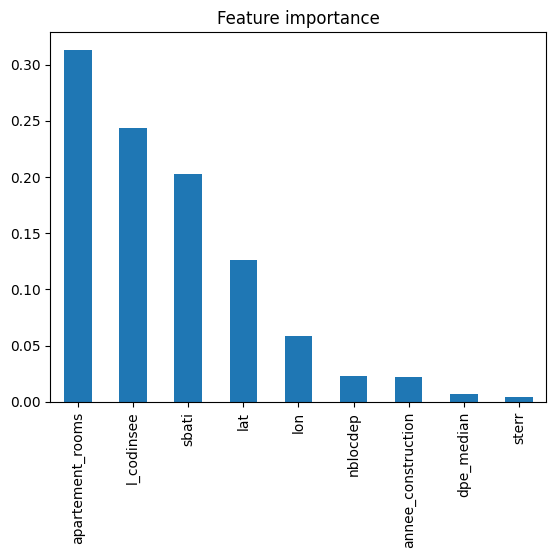

In [32]:
importance_apartements = pd.Series(model_apartements.feature_importances_, index=features).sort_values(ascending=False)
print(importance_apartements)
importance_apartements.plot(kind="bar", title="Feature importance")
